# Objectives

In the notebook, named Madgwick_and_calculated_angular_velocity_comparison.ipynb, shows that estimated euler angle is almost similar to the angles provided by OXTS. With regard to the forward velocity, our estimation is shows relatively close to the forward velocity provided by OXTS, which is assumed to be obtained by combination of GPS displacement and some kind of filter to smooth the values as shown in the notebook named gps_displacement_vs_forward_velocity_comparison_test.ipynb.

Now, we have three setups, Setup1(IMU, VO), Setup2(IMU, VO+GPS), Setup3(INS(forward velocity), VO+GPS) and we agreed upon that Setup3 has a robust estimation than the other setups in terms of overall experiments and the IMU-only filter experiment.

#### Hence, it is worth trying to implement Setup3, which uses velocity motion model, with estimated forward velocity and z-axis angular velocity to localize the vehicle.

The implementation is shown in the figure below:

<img src="../../../../assets/new-setup.jpg" />

As shown in the figure, there are two filters connected sequentially. The first filter, EKF, introduces Setup1 motion model that uses IMU's linear acceleration and angular velocity to estimate state of the system. In the measurement update step in the EKF, it takes VO to correct position and velocity, which is obtained by displacement / delta time. After correction step, the forward velocity from the EKF and z-axis angular velocity are fed to the second filter to propagate the state based on the velocity motion model in Setup3, then the state is corrected by either VO or VO+GPS.

In this experiment, GPS dropout rate is set to 1.0 meaning that the environment is GPS-denied environment. Moreover, the dropout rate of Visual Odometry is increased by 0.1 until it reaches 0.4 and compare the result with Setup1 for all filters.

# Implementation

In [53]:
import os
import sys
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
sys.path.append('/app/src')
from data_loader import DataLoader, CustomDataLoader
from configs.configs import (
    SetupEnum, FilterEnum, NoiseTypeEnum, MeasurementDataEnum, ErrorEnum
)
from kalman_filters import (
    ExtendedKalmanFilter, InternalExtendedKalmanFilter,
    UnscentedKalmanFilter,
    EnsembleKalmanFilter,
    ParticleFilter, ResamplingAlgorithms,
    CubatureKalmanFilter,

    FilterWrapper
)
from utils.error_report import get_error_report, print_error_report, get_error_from_list


%matplotlib inline
np.random.seed(777)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


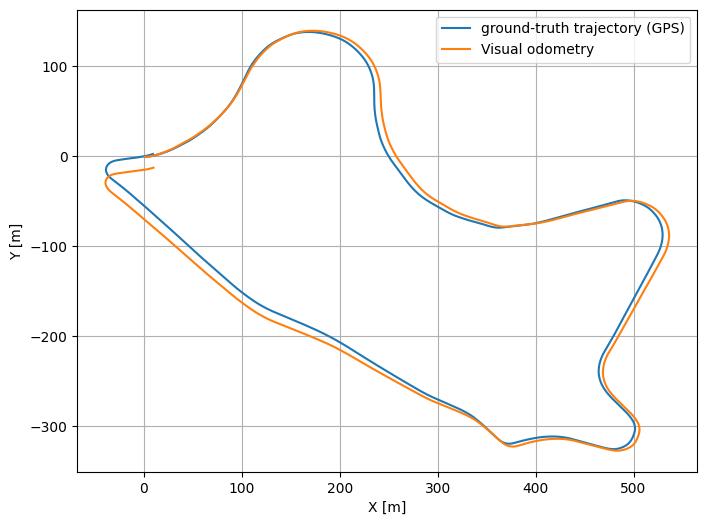

In [2]:
root_path = '../../../../'
kitti_root_dir = os.path.join(root_path, "data")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0033'

# Dropping all measurement data results in IMU-only estimation
data = CustomDataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=0.0, 
    gps_dropout_ratio=1.0,
    visualize_data=True
)

# Filters in experimental setup (estimated forward velocity + angular velocity, VO)

## EKF

[EKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 5852.59it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.851 m
Root Mean Squared Error: 5.471 m
Maximum Error: 16.4 m
-----------------------------------------------



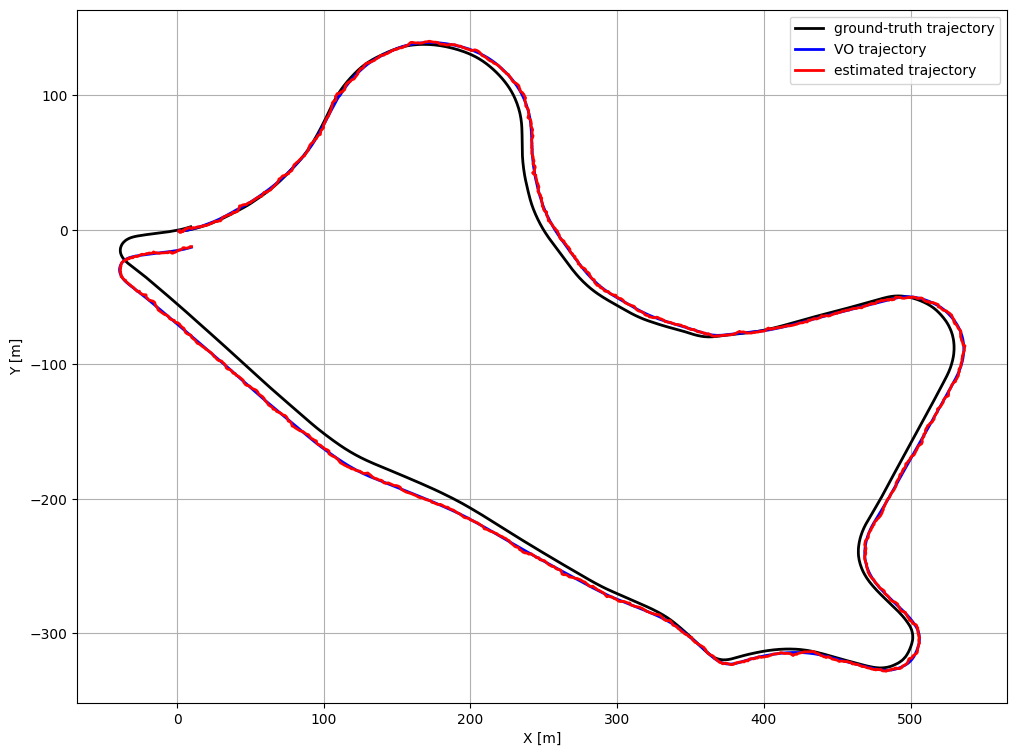

In [10]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EKF,
    noise_type=NoiseTypeEnum.CURRENT
)

_ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
ekf_0 = FilterWrapper(
    main_filter=_ekf,
    filter_type=FilterEnum.EKF,
)
error_ekf_0 = ekf_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## UKF

[UKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4445.36it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.899 m
Root Mean Squared Error: 5.511 m
Maximum Error: 16.491 m
-----------------------------------------------



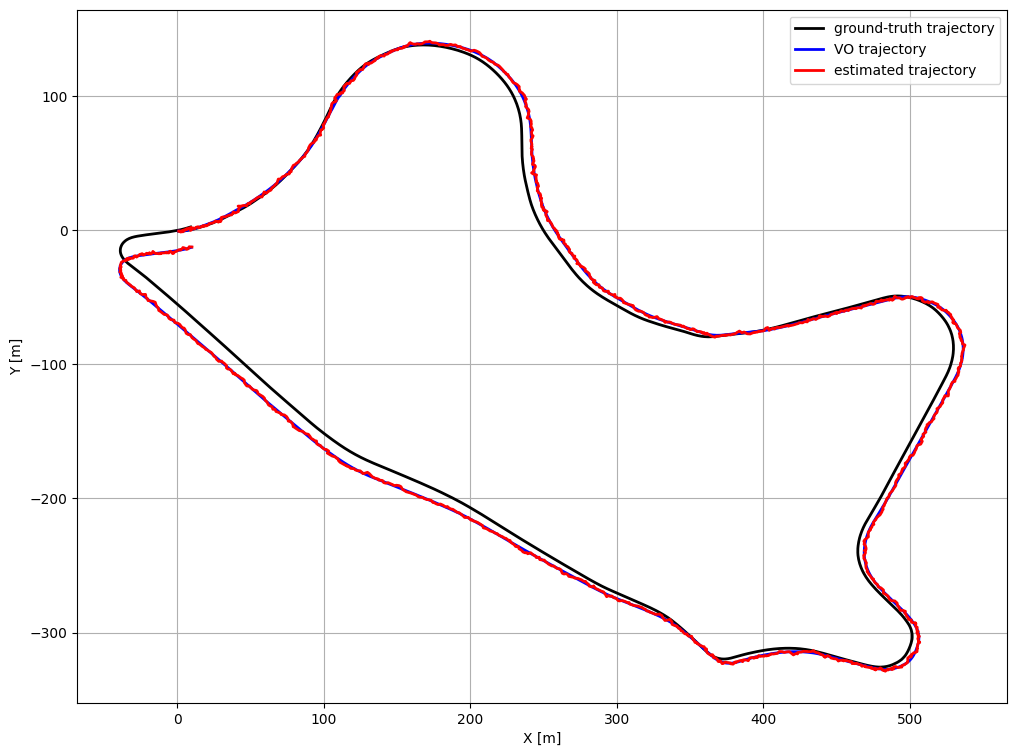

In [11]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF,
    noise_type=NoiseTypeEnum.CURRENT
)

alpha = 1.0
beta = 2.0
kappa = 0.0

_ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    alpha=alpha, 
    beta=beta, 
    kappa=kappa,
    setup=SetupEnum.SETUP_3
)
ukf_0 = FilterWrapper(
    main_filter=_ukf,
    filter_type=FilterEnum.UKF,
)
error_ukf_0 = ukf_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## PF

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:03<00:00, 421.68it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.932 m
Root Mean Squared Error: 5.524 m
Maximum Error: 17.367 m
----------------------------------------------



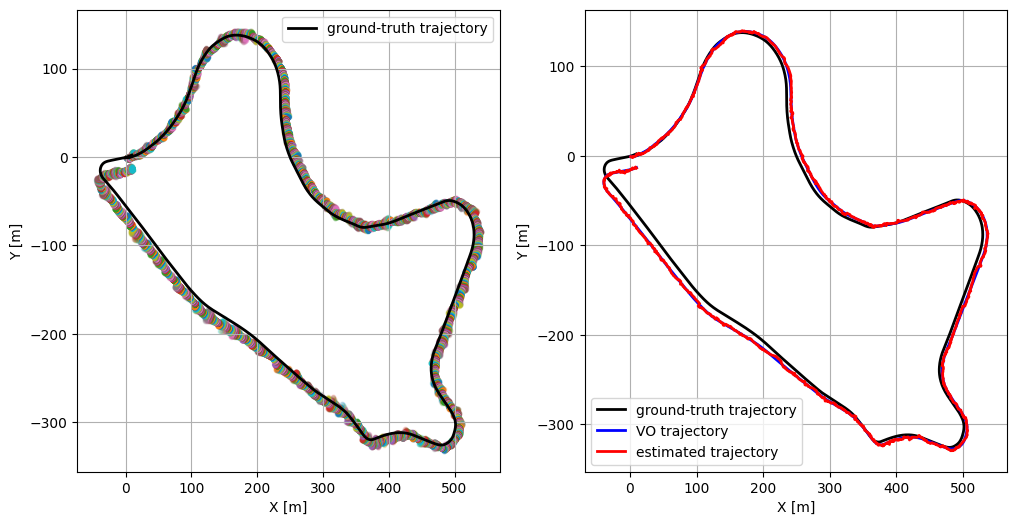

In [12]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.PF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_pf = ParticleFilter(
    N=64, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=ResamplingAlgorithms.RESIDUAL
)
_pf.create_gaussian_particles(mean=x.copy(), var=P.copy())

pf_0 = FilterWrapper(
    main_filter=_pf,
    filter_type=FilterEnum.PF,
)
error_pf_0 = pf_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## EnKF

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 614.30it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 4.042 m
Root Mean Squared Error: 5.625 m
Maximum Error: 18.86 m
------------------------------------------------



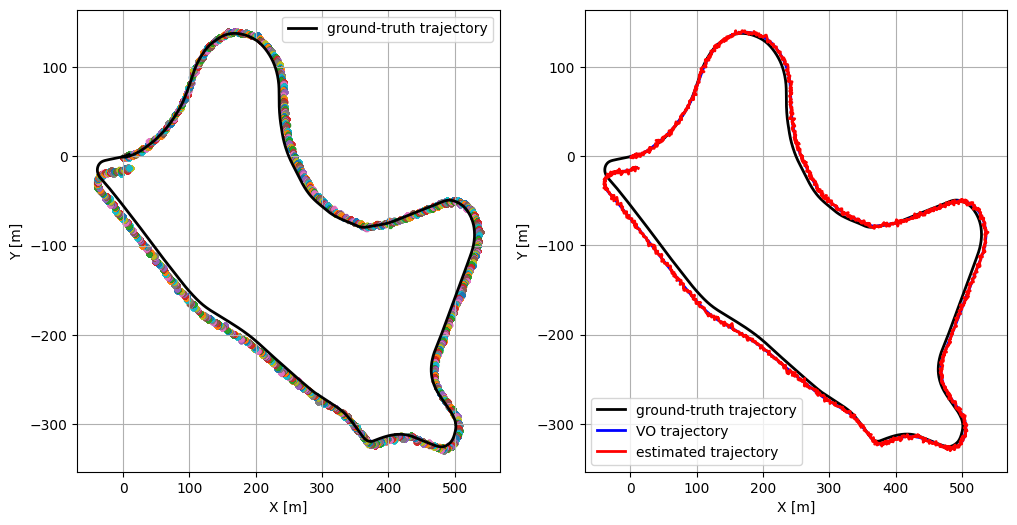

In [13]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EnKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_enkf = EnsembleKalmanFilter(
    N=64, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
enkf_0 = FilterWrapper(
    main_filter=_enkf,
    filter_type=FilterEnum.EnKF,
)
error_enkf_0 = enkf_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## CKF

[CKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4730.14it/s]



----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.899 m
Root Mean Squared Error: 5.511 m
Maximum Error: 16.49 m
-----------------------------------------------



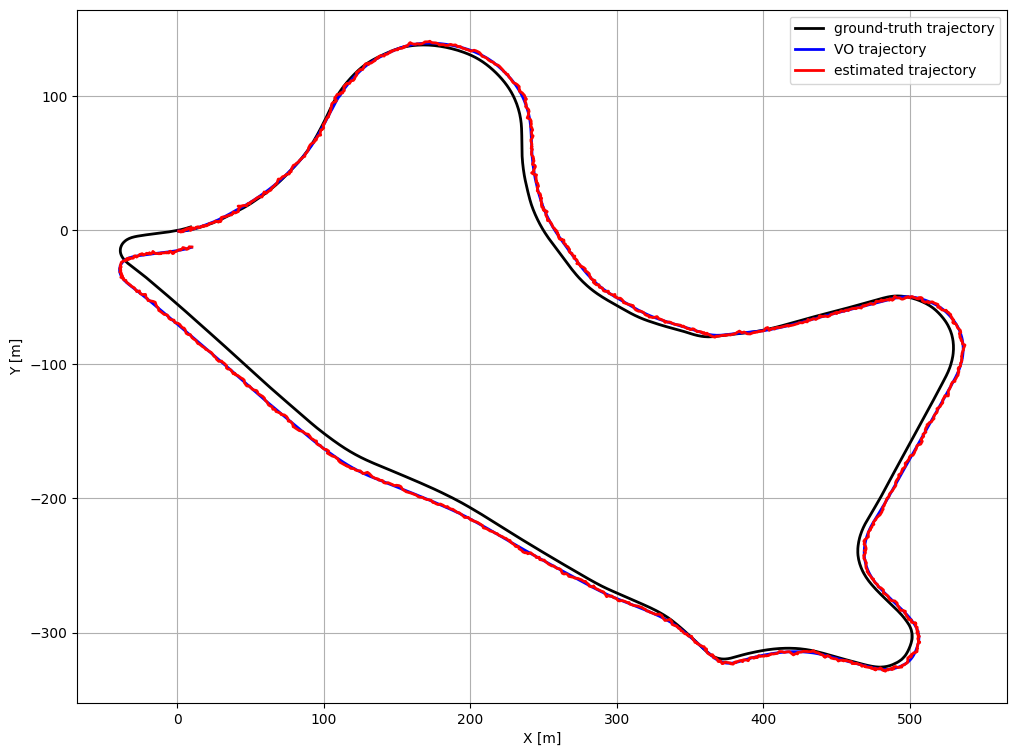

In [14]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.CKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
)
ckf_0 = FilterWrapper(
    main_filter=_ckf,
    filter_type=FilterEnum.CKF,
)
error_ckf_0 = ckf_0.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

# Set VO dropout 0.1

In [15]:
data.change_dropout_ratio(vo_dropout_ratio=0.1, gps_dropout_ratio=1.0)

## EKF

[EKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6827.13it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.844 m
Root Mean Squared Error: 5.442 m
Maximum Error: 15.934 m
-----------------------------------------------



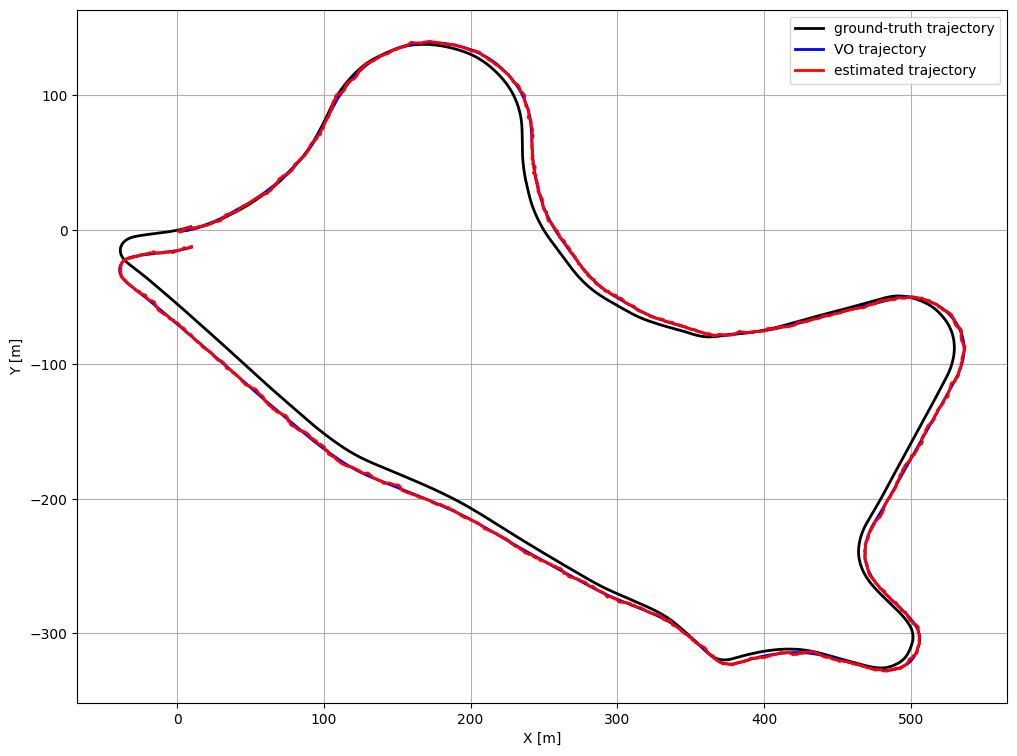

In [16]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EKF,
    noise_type=NoiseTypeEnum.CURRENT
)

_ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
ekf_10 = FilterWrapper(
    main_filter=_ekf,
    filter_type=FilterEnum.EKF,
)
error_ekf_10 = ekf_10.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## UKF

[UKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4587.02it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.887 m
Root Mean Squared Error: 5.476 m
Maximum Error: 16.446 m
-----------------------------------------------



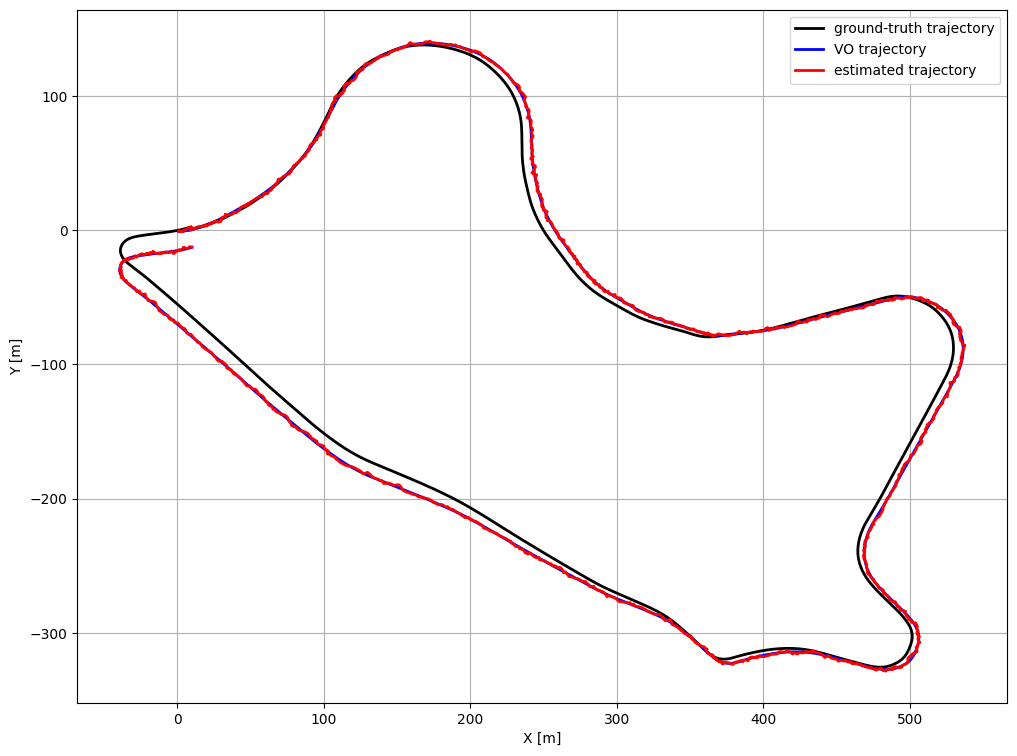

In [17]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF,
    noise_type=NoiseTypeEnum.CURRENT
)

alpha = 1.0
beta = 2.0
kappa = 0.0

_ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    alpha=alpha, 
    beta=beta, 
    kappa=kappa,
    setup=SetupEnum.SETUP_3
)
ukf_10 = FilterWrapper(
    main_filter=_ukf,
    filter_type=FilterEnum.UKF,
)
error_ukf_10 = ukf_10.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## PF

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:03<00:00, 434.05it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.892 m
Root Mean Squared Error: 5.515 m
Maximum Error: 17.101 m
----------------------------------------------



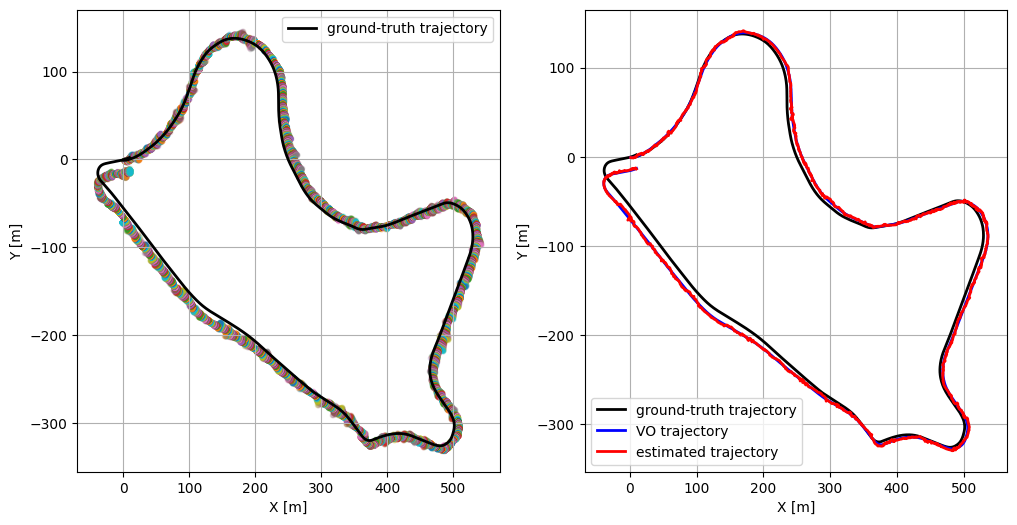

In [18]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.PF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_pf = ParticleFilter(
    N=64, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=ResamplingAlgorithms.RESIDUAL
)
_pf.create_gaussian_particles(mean=x.copy(), var=P.copy())

pf_10 = FilterWrapper(
    main_filter=_pf,
    filter_type=FilterEnum.PF,
)
error_pf_10 = pf_10.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## EnKF

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 611.80it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 4.008 m
Root Mean Squared Error: 5.581 m
Maximum Error: 19.392 m
------------------------------------------------



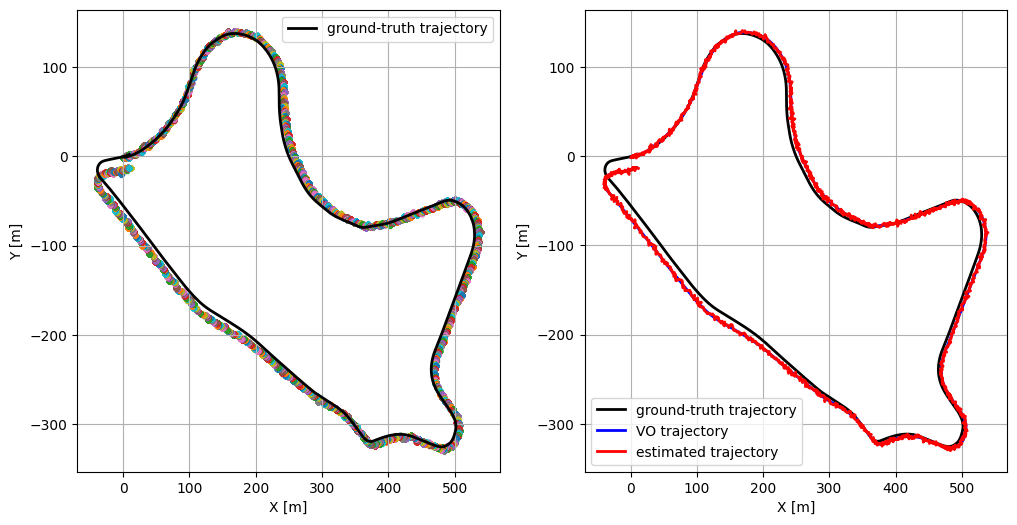

In [19]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EnKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_enkf = EnsembleKalmanFilter(
    N=64, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
enkf_10 = FilterWrapper(
    main_filter=_enkf,
    filter_type=FilterEnum.EnKF,
)
error_enkf_10 = enkf_10.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## CKF

[CKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4114.54it/s]



----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.887 m
Root Mean Squared Error: 5.476 m
Maximum Error: 16.446 m
-----------------------------------------------



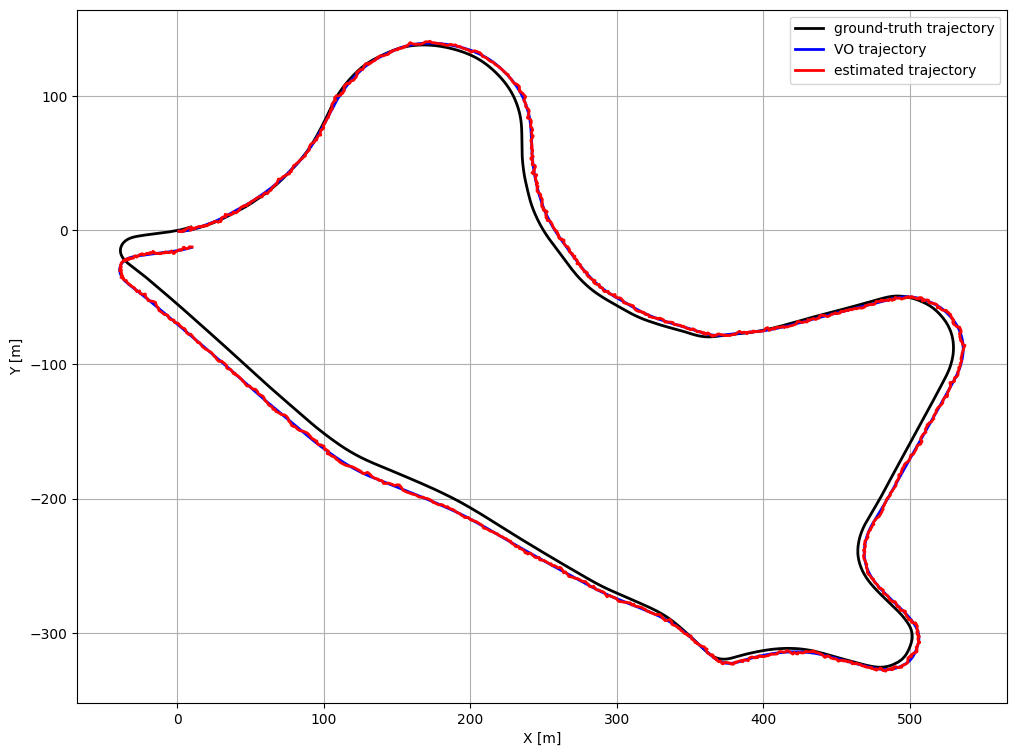

In [20]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.CKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
)
ckf_10 = FilterWrapper(
    main_filter=_ckf,
    filter_type=FilterEnum.CKF,
)
error_ckf_10 = ckf_10.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

# Set VO dropout 0.2

In [21]:
data.change_dropout_ratio(vo_dropout_ratio=0.2, gps_dropout_ratio=1.0)

## EKF

[EKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6932.21it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.853 m
Root Mean Squared Error: 5.448 m
Maximum Error: 15.957 m
-----------------------------------------------



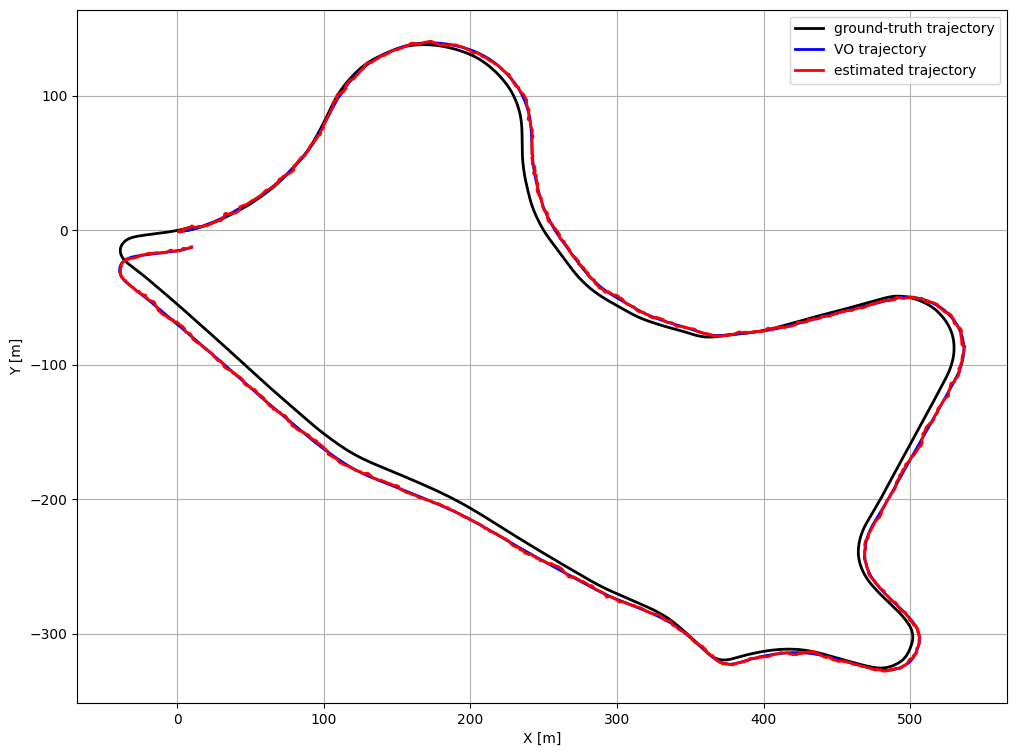

In [22]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EKF,
    noise_type=NoiseTypeEnum.CURRENT
)

_ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
ekf_20 = FilterWrapper(
    main_filter=_ekf,
    filter_type=FilterEnum.EKF,
)
error_ekf_20 = ekf_20.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## UKF

[UKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4602.11it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.896 m
Root Mean Squared Error: 5.485 m
Maximum Error: 16.408 m
-----------------------------------------------



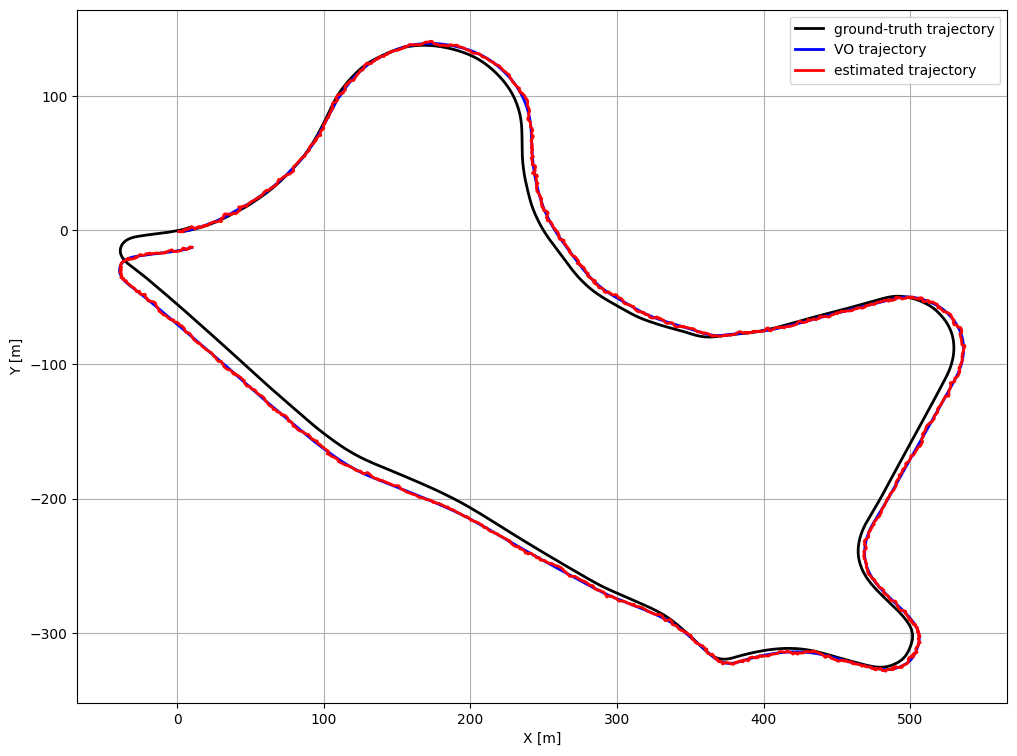

In [23]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF,
    noise_type=NoiseTypeEnum.CURRENT
)

alpha = 1.0
beta = 2.0
kappa = 0.0

_ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    alpha=alpha, 
    beta=beta, 
    kappa=kappa,
    setup=SetupEnum.SETUP_3
)
ukf_20 = FilterWrapper(
    main_filter=_ukf,
    filter_type=FilterEnum.UKF,
)
error_ukf_20 = ukf_20.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## PF

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:03<00:00, 430.77it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.829 m
Root Mean Squared Error: 5.431 m
Maximum Error: 16.357 m
----------------------------------------------



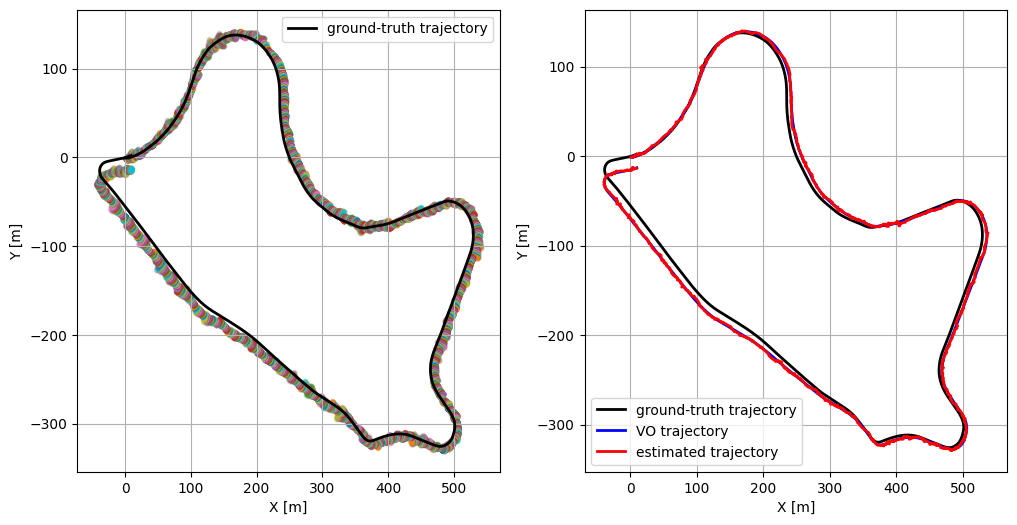

In [24]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.PF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_pf = ParticleFilter(
    N=64, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=ResamplingAlgorithms.RESIDUAL
)
_pf.create_gaussian_particles(mean=x.copy(), var=P.copy())

pf_20 = FilterWrapper(
    main_filter=_pf,
    filter_type=FilterEnum.PF,
)
error_pf_20 = pf_20.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## EnKF

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 627.42it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 4.02 m
Root Mean Squared Error: 5.578 m
Maximum Error: 17.308 m
------------------------------------------------



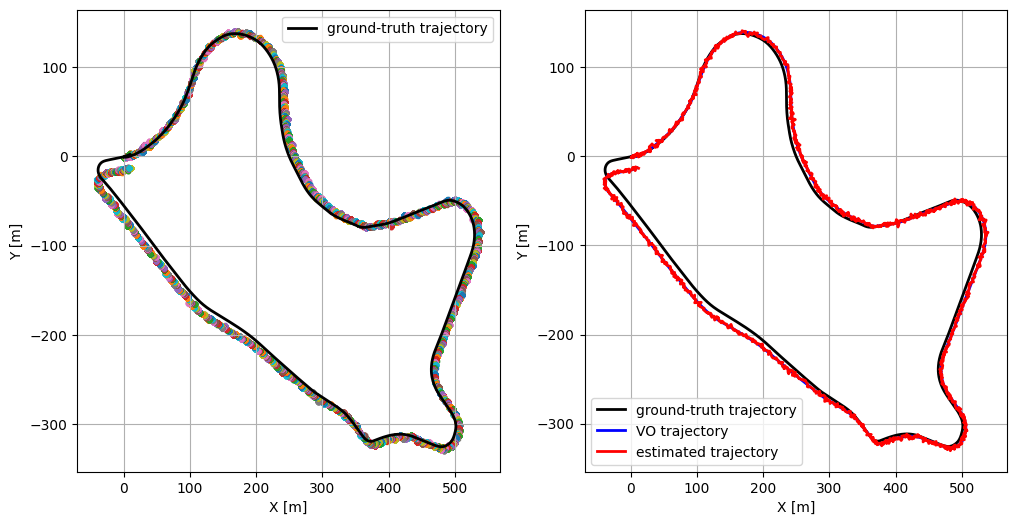

In [25]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EnKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_enkf = EnsembleKalmanFilter(
    N=64, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
enkf_20 = FilterWrapper(
    main_filter=_enkf,
    filter_type=FilterEnum.EnKF,
)
error_enkf_20 = enkf_20.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## CKF

[CKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 3229.46it/s]



----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.896 m
Root Mean Squared Error: 5.485 m
Maximum Error: 16.414 m
-----------------------------------------------



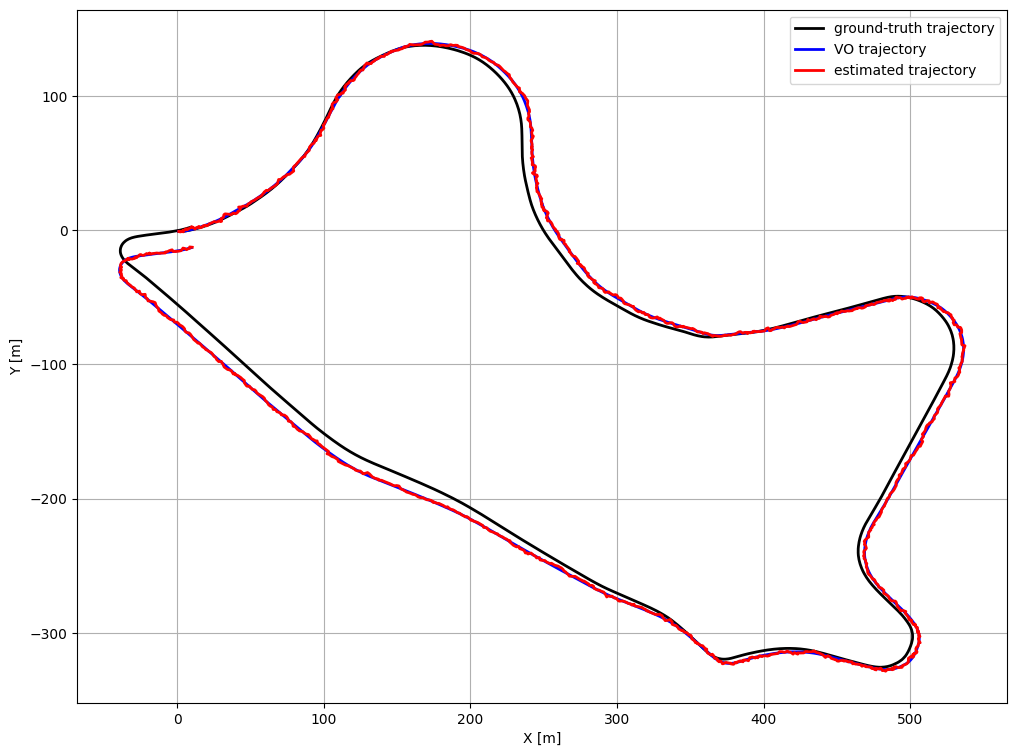

In [26]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.CKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
)
ckf_20 = FilterWrapper(
    main_filter=_ckf,
    filter_type=FilterEnum.CKF,
)
error_ckf_20 = ckf_20.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

# Set VO dropout 0.3

In [27]:
data.change_dropout_ratio(vo_dropout_ratio=0.3, gps_dropout_ratio=1.0)

## EKF

[EKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6644.19it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.857 m
Root Mean Squared Error: 5.45 m
Maximum Error: 15.76 m
-----------------------------------------------



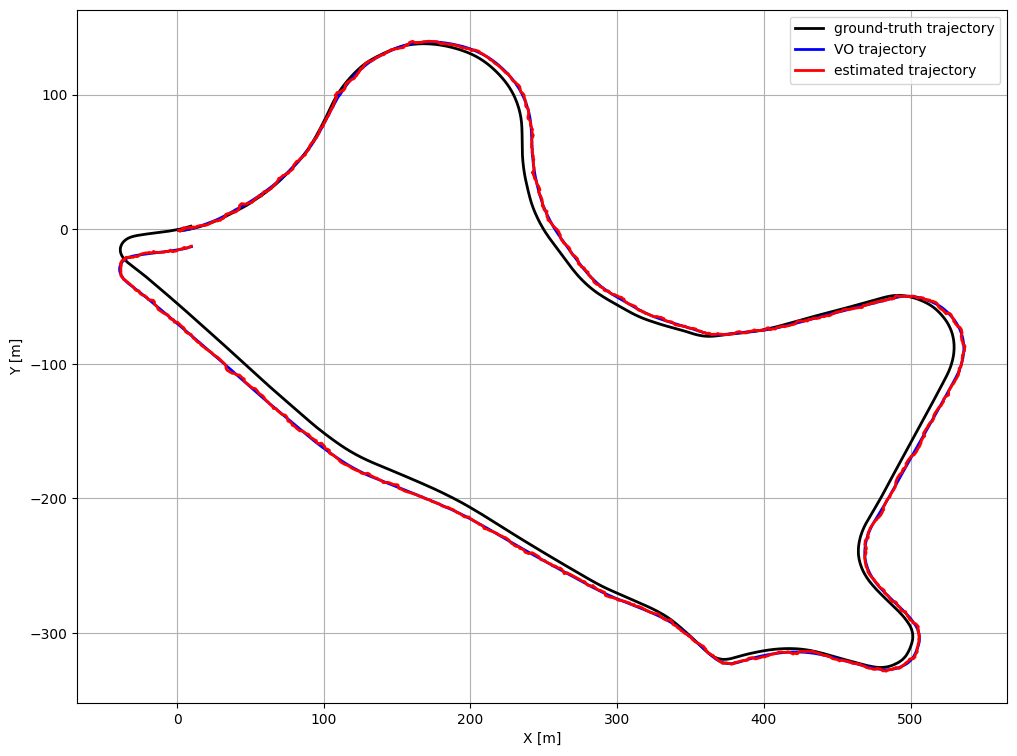

In [28]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EKF,
    noise_type=NoiseTypeEnum.CURRENT
)

_ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
ekf_30 = FilterWrapper(
    main_filter=_ekf,
    filter_type=FilterEnum.EKF,
)
error_ekf_30 = ekf_30.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## UKF

[UKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4791.60it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.901 m
Root Mean Squared Error: 5.489 m
Maximum Error: 16.232 m
-----------------------------------------------



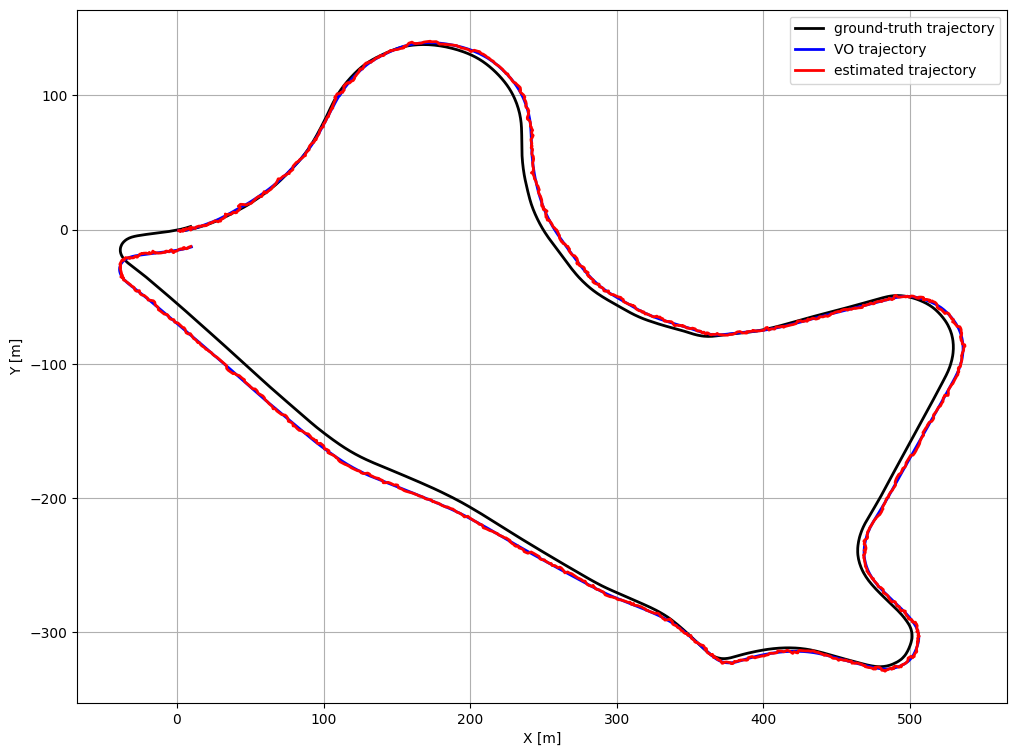

In [29]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF,
    noise_type=NoiseTypeEnum.CURRENT
)

alpha = 1.0
beta = 2.0
kappa = 0.0

_ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    alpha=alpha, 
    beta=beta, 
    kappa=kappa,
    setup=SetupEnum.SETUP_3
)
ukf_30 = FilterWrapper(
    main_filter=_ukf,
    filter_type=FilterEnum.UKF,
)
error_ukf_30 = ukf_30.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## PF

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:03<00:00, 455.05it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.834 m
Root Mean Squared Error: 5.452 m
Maximum Error: 16.3 m
----------------------------------------------



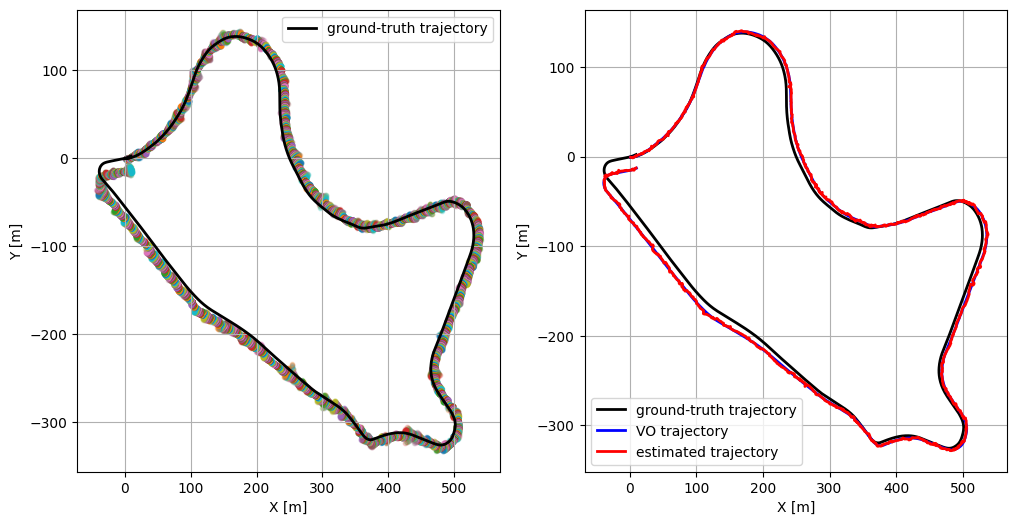

In [30]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.PF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_pf = ParticleFilter(
    N=64, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=ResamplingAlgorithms.RESIDUAL
)
_pf.create_gaussian_particles(mean=x.copy(), var=P.copy())

pf_30 = FilterWrapper(
    main_filter=_pf,
    filter_type=FilterEnum.PF,
)
error_pf_30 = pf_30.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## EnKF

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 651.22it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 4.044 m
Root Mean Squared Error: 5.617 m
Maximum Error: 18.89 m
------------------------------------------------



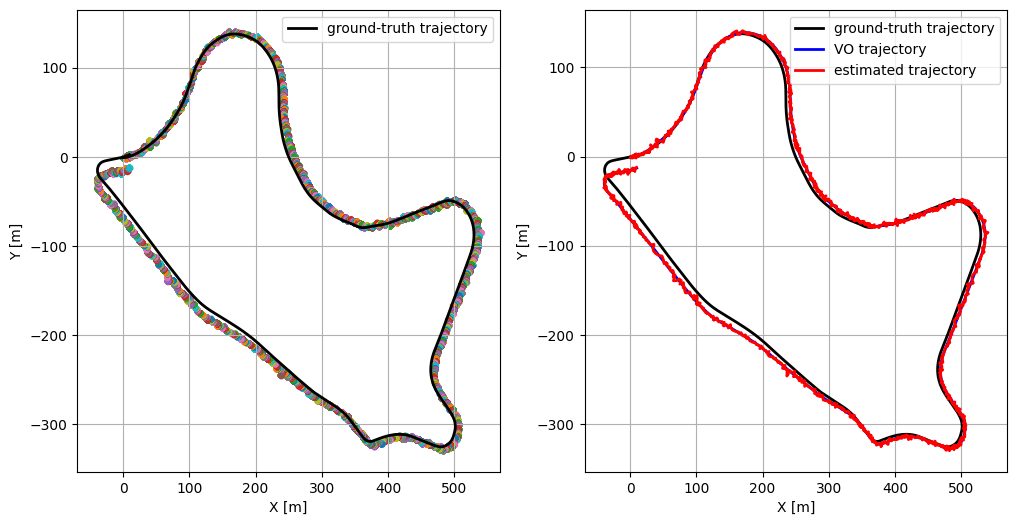

In [31]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EnKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_enkf = EnsembleKalmanFilter(
    N=64, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
enkf_30 = FilterWrapper(
    main_filter=_enkf,
    filter_type=FilterEnum.EnKF,
)
error_enkf_30 = enkf_30.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## CKF

[CKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4795.58it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.901 m
Root Mean Squared Error: 5.49 m
Maximum Error: 16.232 m
-----------------------------------------------



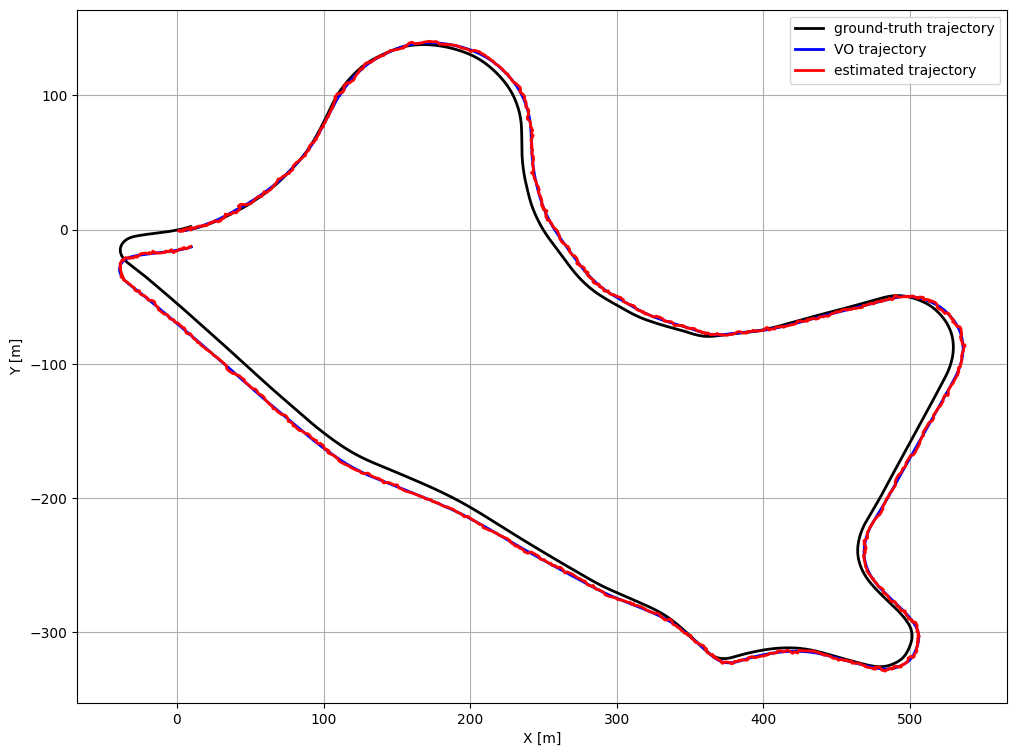

In [32]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.CKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
)
ckf_30 = FilterWrapper(
    main_filter=_ckf,
    filter_type=FilterEnum.CKF,
)
error_ckf_30 = ckf_30.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

# Set VO dropout 0.4

In [33]:
data.change_dropout_ratio(vo_dropout_ratio=0.4, gps_dropout_ratio=1.0)

## EKF

[EKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6787.29it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.848 m
Root Mean Squared Error: 5.459 m
Maximum Error: 16.412 m
-----------------------------------------------



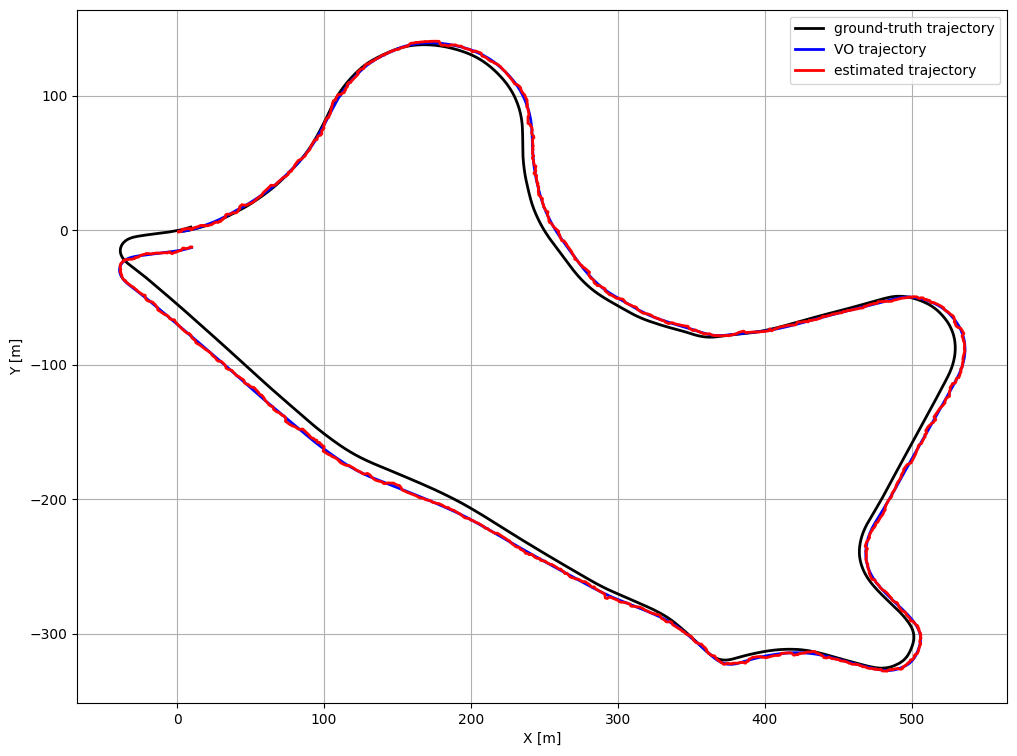

In [34]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EKF,
    noise_type=NoiseTypeEnum.CURRENT
)

_ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
ekf_40 = FilterWrapper(
    main_filter=_ekf,
    filter_type=FilterEnum.EKF,
)
error_ekf_40 = ekf_40.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## UKF

[UKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 5346.50it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.89 m
Root Mean Squared Error: 5.504 m
Maximum Error: 16.615 m
-----------------------------------------------



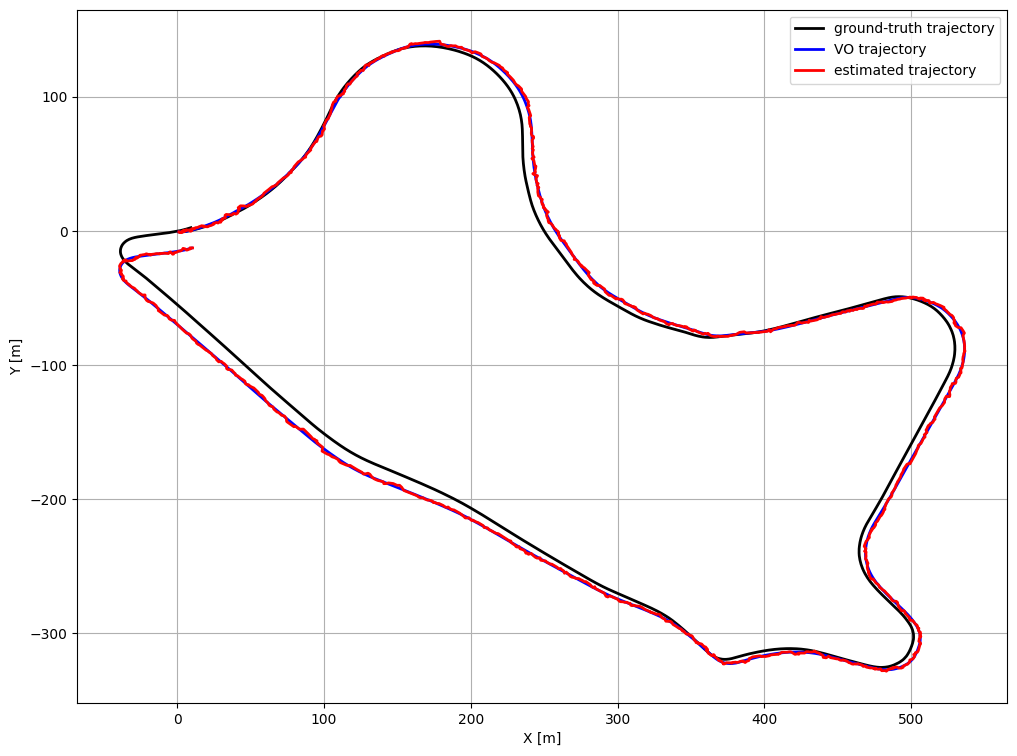

In [35]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF,
    noise_type=NoiseTypeEnum.CURRENT
)

alpha = 1.0
beta = 2.0
kappa = 0.0

_ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    alpha=alpha, 
    beta=beta, 
    kappa=kappa,
    setup=SetupEnum.SETUP_3
)
ukf_40 = FilterWrapper(
    main_filter=_ukf,
    filter_type=FilterEnum.UKF,
)
error_ukf_40 = ukf_40.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## PF

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:03<00:00, 460.51it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.807 m
Root Mean Squared Error: 5.438 m
Maximum Error: 16.744 m
----------------------------------------------



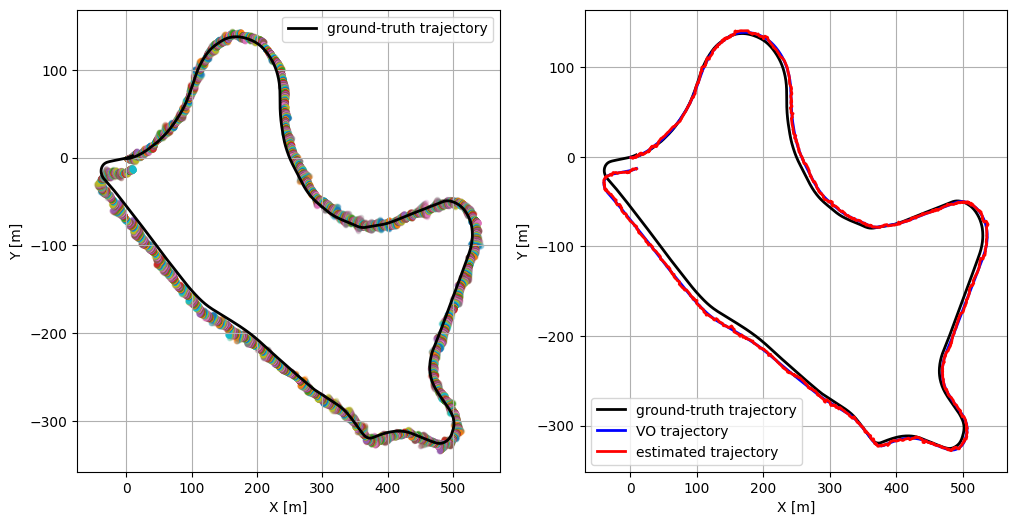

In [36]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.PF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_pf = ParticleFilter(
    N=64, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=ResamplingAlgorithms.RESIDUAL
)
_pf.create_gaussian_particles(mean=x.copy(), var=P.copy())

pf_40 = FilterWrapper(
    main_filter=_pf,
    filter_type=FilterEnum.PF,
)
error_pf_40 = pf_40.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## EnKF

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 657.65it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 4.05 m
Root Mean Squared Error: 5.632 m
Maximum Error: 18.575 m
------------------------------------------------



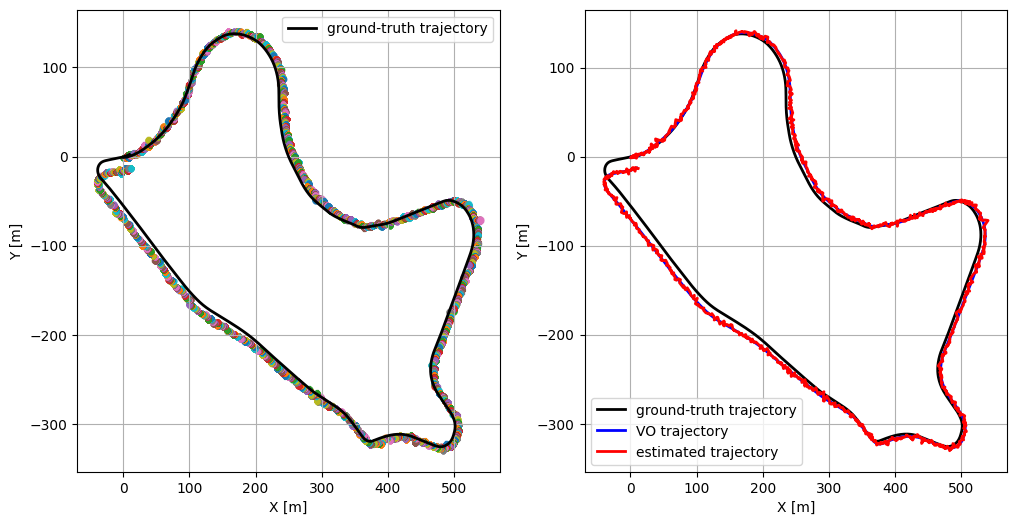

In [37]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EnKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_enkf = EnsembleKalmanFilter(
    N=64, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
enkf_40 = FilterWrapper(
    main_filter=_enkf,
    filter_type=FilterEnum.EnKF,
)
error_enkf_40 = enkf_40.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## CKF

[CKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 5397.53it/s]



----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.89 m
Root Mean Squared Error: 5.503 m
Maximum Error: 16.616 m
-----------------------------------------------



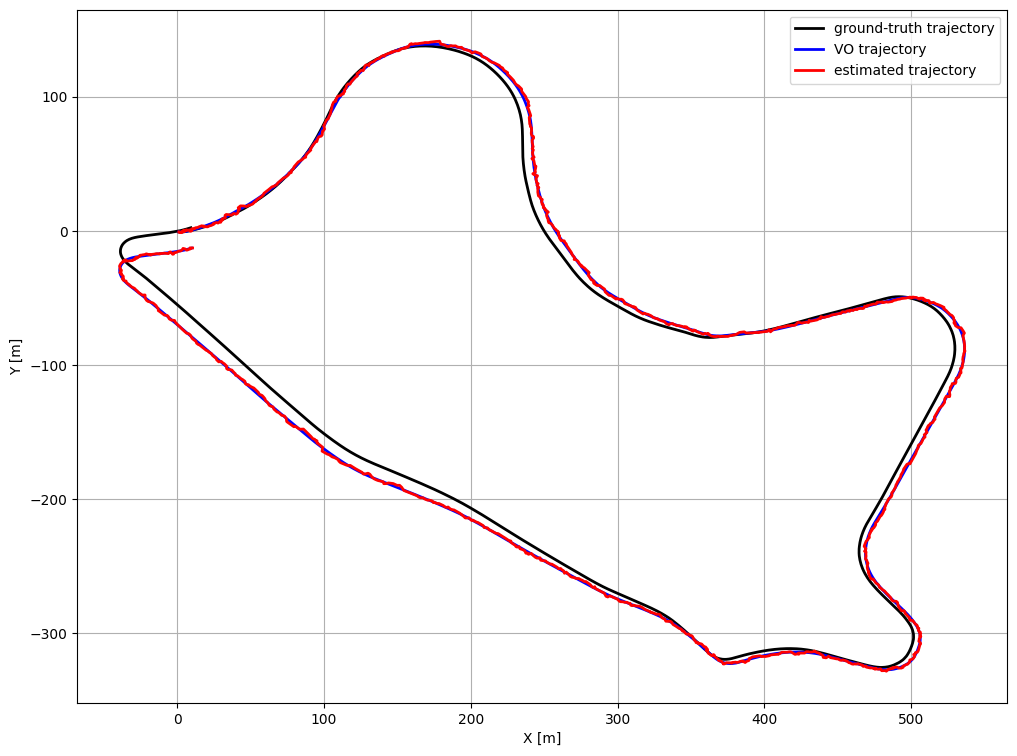

In [38]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.CKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
)
ckf_40 = FilterWrapper(
    main_filter=_ckf,
    filter_type=FilterEnum.CKF,
)
error_ckf_40 = ckf_40.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

# Set VO dropout 0.9

In [39]:
data.change_dropout_ratio(vo_dropout_ratio=0.9, gps_dropout_ratio=1.0)

## EKF

[EKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4439.70it/s]


----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.99 m
Root Mean Squared Error: 5.466 m
Maximum Error: 15.816 m
-----------------------------------------------



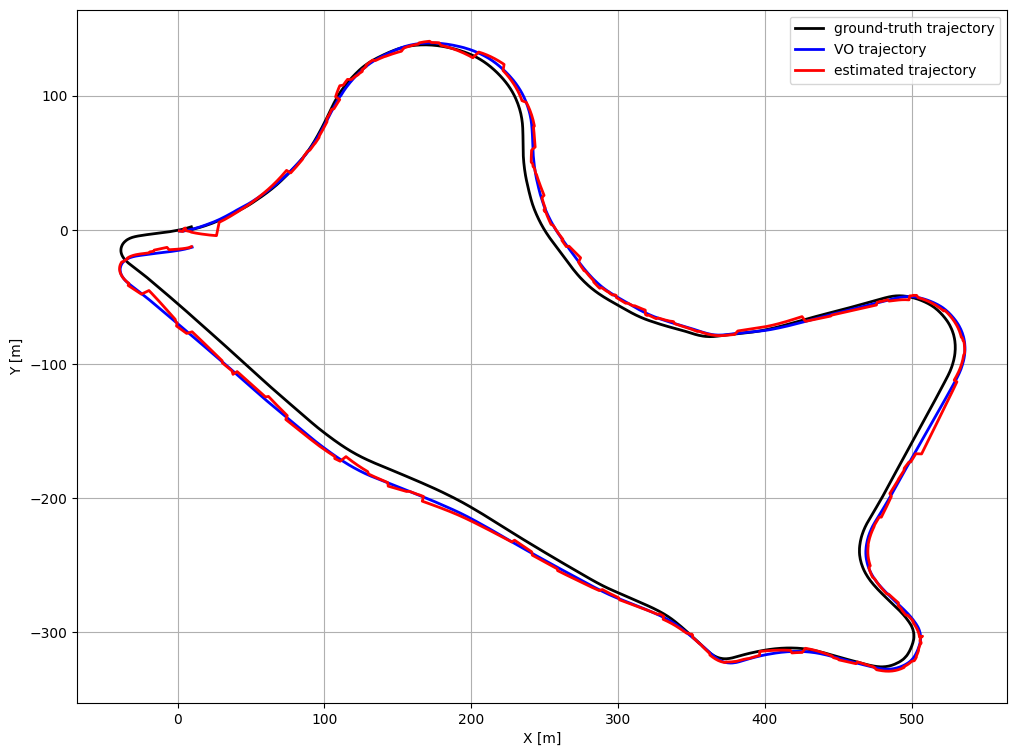

In [40]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EKF,
    noise_type=NoiseTypeEnum.CURRENT
)

_ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
ekf_90 = FilterWrapper(
    main_filter=_ekf,
    filter_type=FilterEnum.EKF,
)
error_ekf_90 = ekf_90.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## UKF

[UKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 5905.83it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 4.829 m
Root Mean Squared Error: 6.73 m
Maximum Error: 24.705 m
-----------------------------------------------



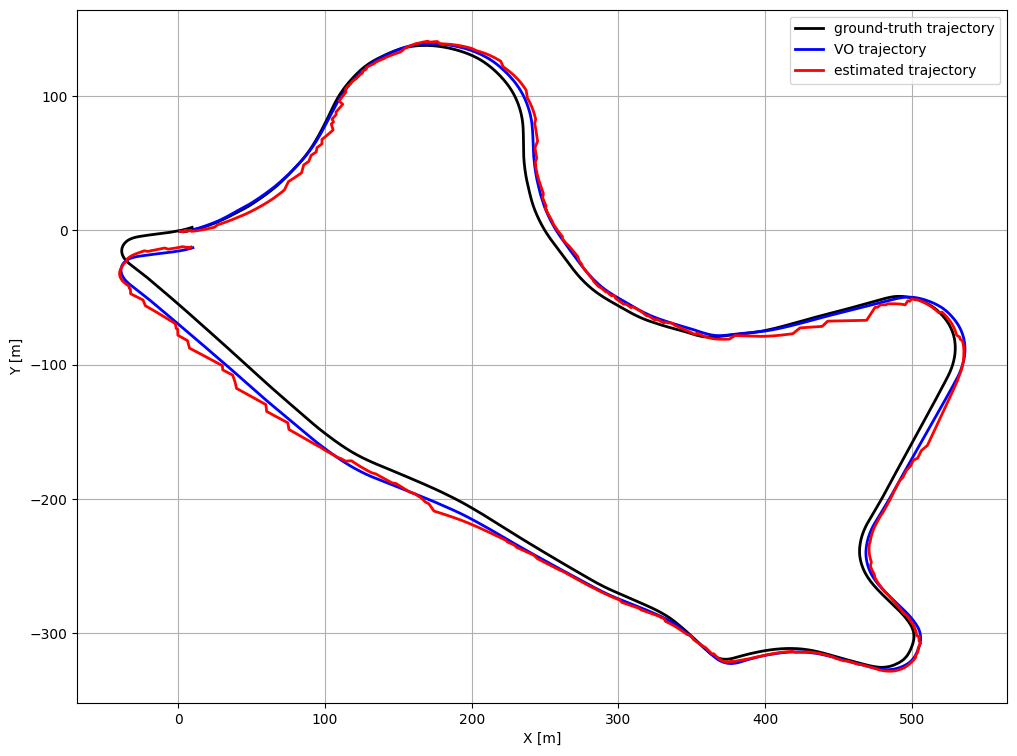

In [41]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF,
    noise_type=NoiseTypeEnum.CURRENT
)

alpha = 1.0
beta = 2.0
kappa = 0.0

_ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    alpha=alpha, 
    beta=beta, 
    kappa=kappa,
    setup=SetupEnum.SETUP_3
)
ukf_90 = FilterWrapper(
    main_filter=_ukf,
    filter_type=FilterEnum.UKF,
)
error_ukf_90 = ukf_90.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## PF

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 663.62it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.986 m
Root Mean Squared Error: 5.558 m
Maximum Error: 23.459 m
----------------------------------------------



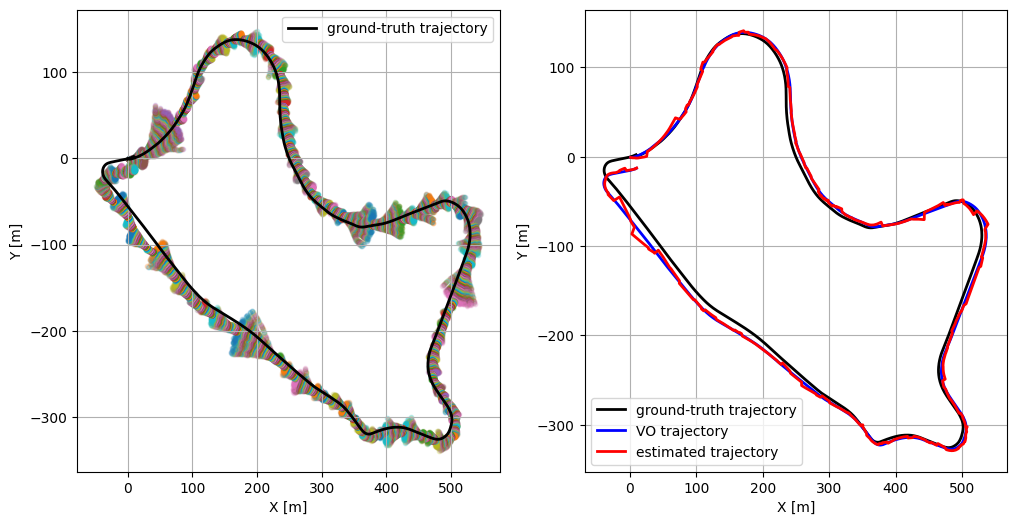

In [42]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.PF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_pf = ParticleFilter(
    N=64, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=ResamplingAlgorithms.RESIDUAL
)
_pf.create_gaussian_particles(mean=x.copy(), var=P.copy())

pf_90 = FilterWrapper(
    main_filter=_pf,
    filter_type=FilterEnum.PF,
)
error_pf_90 = pf_90.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## EnKF

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 599.42it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 4.347 m
Root Mean Squared Error: 5.856 m
Maximum Error: 18.924 m
------------------------------------------------



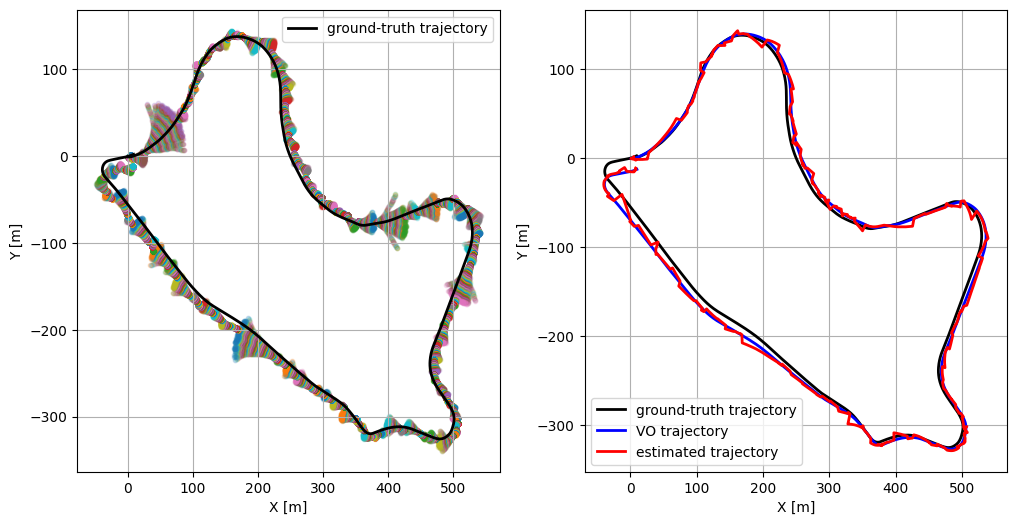

In [43]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EnKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_enkf = EnsembleKalmanFilter(
    N=64, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3
)
enkf_90 = FilterWrapper(
    main_filter=_enkf,
    filter_type=FilterEnum.EnKF,
)
error_enkf_90 = enkf_90.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## CKF

[CKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6633.73it/s]



----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 4.916 m
Root Mean Squared Error: 6.926 m
Maximum Error: 26.999 m
-----------------------------------------------



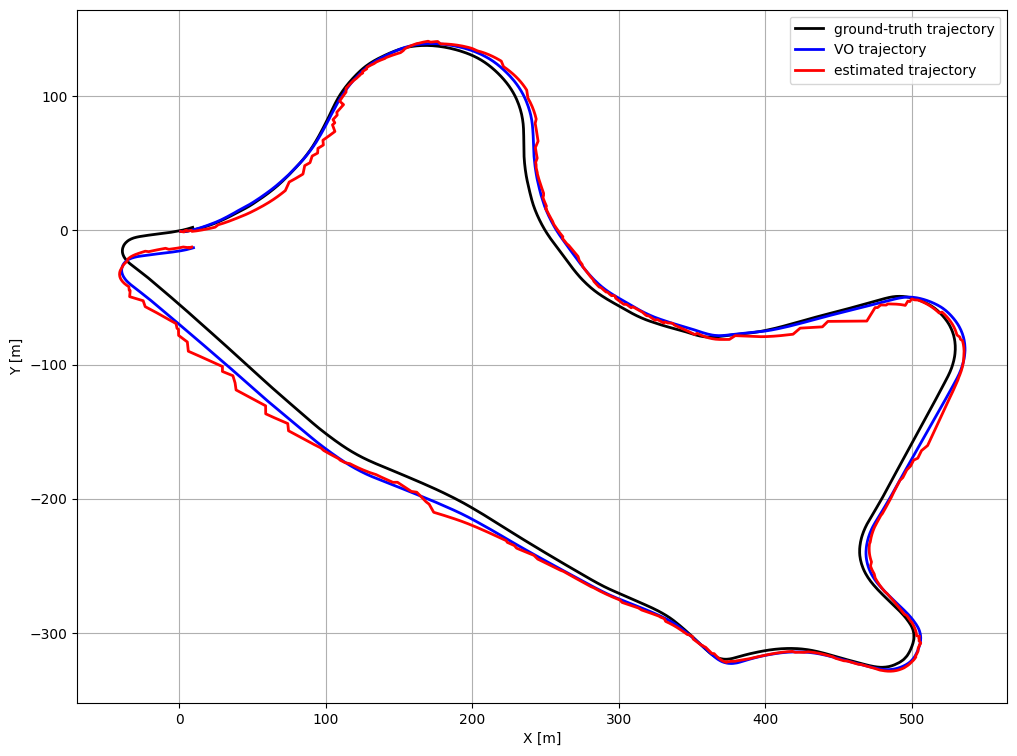

In [44]:
x, P, H, q, r_vo, r_gps = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.CKF, 
    noise_type=NoiseTypeEnum.CURRENT
)

_ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_3,
)
ckf_90 = FilterWrapper(
    main_filter=_ckf,
    filter_type=FilterEnum.CKF,
)
error_ckf_90 = ckf_90.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

# Put all together

In [68]:
columns = ['EKF', 'UKF', 'PF', 'EnKF', 'CKF']
df_dropout_indices = ['No dropout', '10% drop', '20% drop', '30% drop', '40% drop', '90% drop']

def get_error_dataframe(error_0, error_10, error_20, error_30, error_40, error_90):
    mae_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAE)
    mae_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAE)
    mae_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAE)
    mae_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAE)
    mae_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAE)
    mae_90 = get_error_from_list(error_90, e_type=ErrorEnum.MAE)

    rmse_0 = get_error_from_list(error_0, e_type=ErrorEnum.RMSE)
    rmse_10 = get_error_from_list(error_10, e_type=ErrorEnum.RMSE)
    rmse_20 = get_error_from_list(error_20, e_type=ErrorEnum.RMSE)
    rmse_30 = get_error_from_list(error_30, e_type=ErrorEnum.RMSE)
    rmse_40 = get_error_from_list(error_40, e_type=ErrorEnum.RMSE)
    rmse_90 = get_error_from_list(error_90, e_type=ErrorEnum.RMSE)
    
    max_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAX)
    max_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAX)
    max_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAX)
    max_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAX)
    max_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAX)
    max_90 = get_error_from_list(error_90, e_type=ErrorEnum.MAX)
    
    mae_error = [mae_0, mae_10, mae_20, mae_30, mae_40, mae_90]
    rmse_error = [rmse_0, rmse_10, rmse_20, rmse_30, rmse_40, rmse_90]
    max_error = [max_0, max_10, max_20, max_30, max_40, max_90]
    
    mae_df = pd.DataFrame(np.array(mae_error), 
                            index=df_dropout_indices, 
                            columns=columns)
    rmse_df = pd.DataFrame(np.array(rmse_error), 
                            index=df_dropout_indices, 
                            columns=columns)
    max_df = pd.DataFrame(np.array(max_error), 
                            index=df_dropout_indices, 
                            columns=columns)
    
    return mae_df, rmse_df, max_df



In [69]:
errors_0 = [error_ekf_0, error_ukf_0, error_pf_0, error_enkf_0, error_ckf_0]
errors_10 = [error_ekf_10, error_ukf_10, error_pf_10, error_enkf_10, error_ckf_10]
errors_20 = [error_ekf_20, error_ukf_20, error_pf_20, error_enkf_20, error_ckf_20]
errors_30 = [error_ekf_30, error_ukf_30, error_pf_30, error_enkf_30, error_ckf_30]
errors_40 = [error_ekf_40, error_ukf_40, error_pf_40, error_enkf_40, error_ckf_40]
errors_90 = [error_ekf_90, error_ukf_90, error_pf_90, error_enkf_90, error_ckf_90]

In [70]:
mae_df, rmse_df, max_df = get_error_dataframe(errors_0, errors_10, errors_20, errors_30, errors_40, errors_90)

In [71]:
mae_df

,EKF,UKF,PF,EnKF,CKF
No dropout,3.851,3.899,3.932,4.042,3.899
10% drop,3.844,3.887,3.892,4.008,3.887
20% drop,3.853,3.896,3.829,4.020,3.896
30% drop,3.857,3.901,3.834,4.044,3.901
40% drop,3.848,3.890,3.807,4.050,3.890
90% drop,3.990,4.829,3.986,4.347,4.916


# Conclusion

In this notebook, we implemented internal EKF to estimate forward velocity and it is fed to the parent filter. The parent filter employs velocity motion model which assumes that the motion of the vehicle is moved by linear forward velocity and angular velocity.
The result shows that all the filters did not experience significant drop of their performance even VO dropout rate is 90%. Moreover, in comparison to the result of filter estimation in Setup1, sampling based filters, such as Particle Filter and Ensemble Kalman Filter, do not need to increase more than 64, which brings significant reduction of inference time.